# My Final Project
Yadira Lorenzo

In [1]:
import numpy as np
import sep

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
# use astropy routines instead of fitsio
from astropy.io import fits
%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

read an example image from a FITS file and display it, just to show what we’re dealing with. The example image is just 256 x 256 pixels.

In [6]:
# read in data
hdu = fits.open('hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits')

# extract image
data = hdu[0].data

# fix byte order for SEP
data = data.byteswap().view(data.dtype.newbyteorder('='))

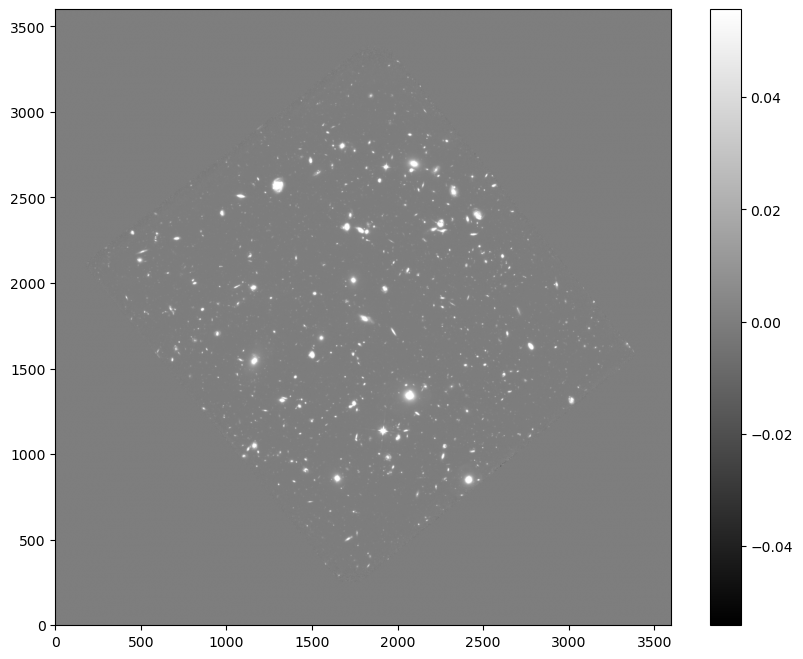

In [19]:
# show image
m, s = np.mean(data), np.std(data)

plt.imshow(data, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.savefig('tutorial_image.png')
plt.show()

In [20]:
# measure a spatially varying background on the image
bkg = sep.Background(data)

This returns an Background object that holds information on the spatially varying background and spatially varying background noise level. We can now do various things with this Background object.

In [21]:
# get a 'global' mean and noise of the image background
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [22]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equavilent to above

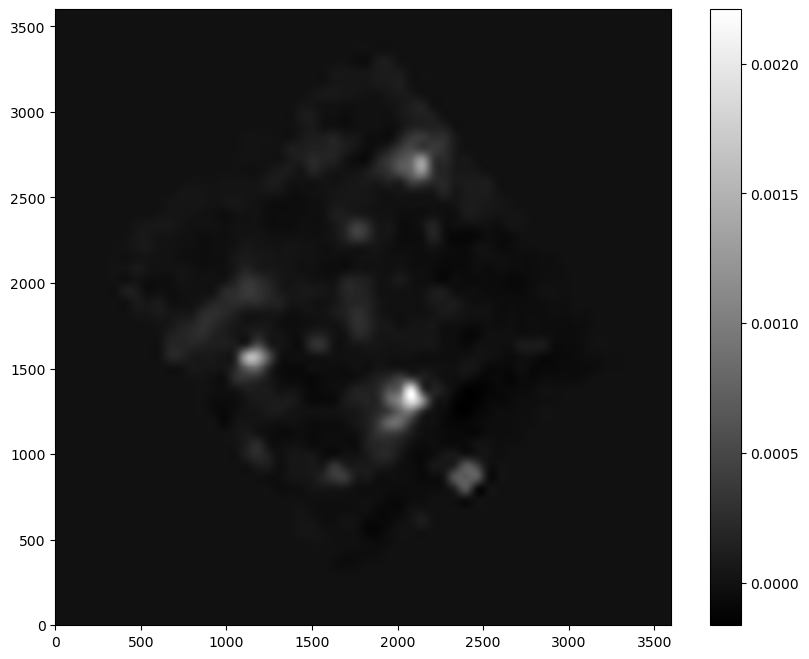

In [27]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig('tutorial_background.png')
plt.show()

In [28]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

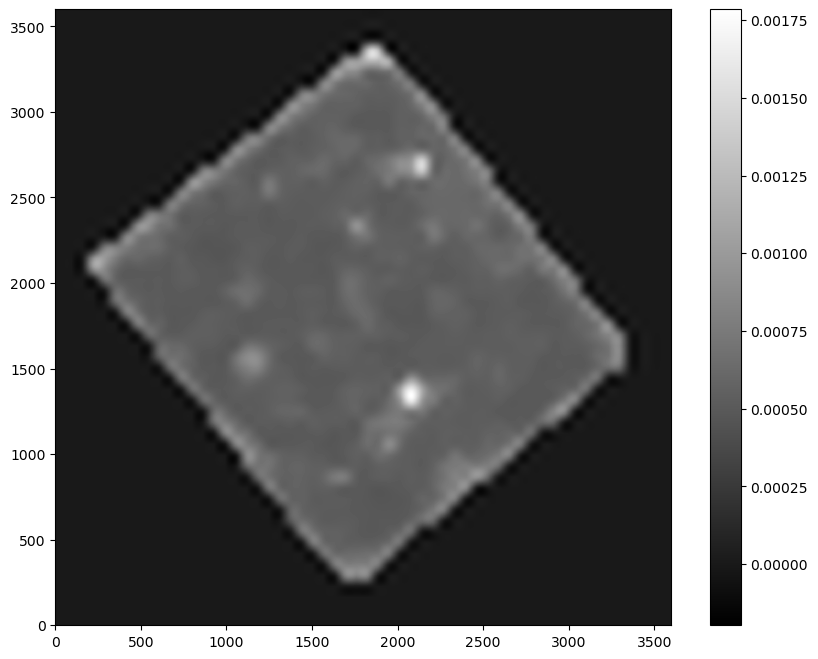

In [29]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig('tutorial_background_noise.png')
plt.show()

In [30]:
# subtract the background
data_sub = data - bkg

# Object Detection
Now that we’ve subtracted the background, we can run object detection on the background-subtracted data. You can see the background noise level is pretty flat. So here we’re setting the detection threshold to be a constant value of 30.0 σ where σ is the global background RMS.

In [45]:
objects = sep.extract(data_sub, 30.0, err=bkg.globalrms)

In [46]:
# how many objects were detected
len(objects)

695

objects['x'] and objects['y'] will give the centroid coordinates of the objects. Just to check where the detected objects are, we’ll over-plot the object coordinates with some basic shape parameters on the image:

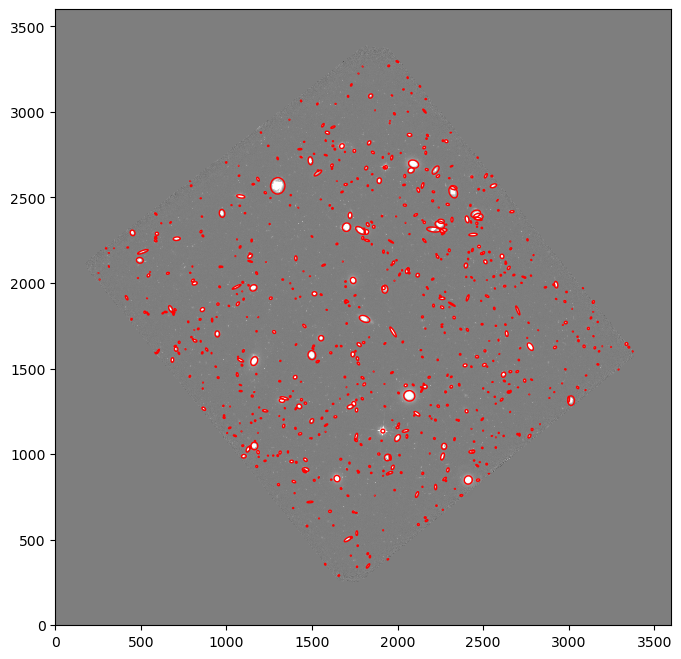

In [47]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]), 
                width=6 * objects['a'][i],
                height=6 * objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

plt.savefig('bubble_objects.png')

In [48]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

# Aperture photometry

we’ll perform simple circular aperture photometry with a 3 pixel radius at the locations of the objects:

In [49]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [50]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 1.152732 +/- 1.073658
object 1: flux = 0.554534 +/- 0.744676
object 2: flux = 1.122580 +/- 1.059523
object 3: flux = 0.875477 +/- 0.935674
object 4: flux = 0.687016 +/- 0.828869
object 5: flux = 0.762608 +/- 0.873279
object 6: flux = 0.496439 +/- 0.704590
object 7: flux = 1.254951 +/- 1.120250
object 8: flux = 0.973171 +/- 0.986499
object 9: flux = 3.211309 +/- 1.792015


# To finish our notebook, we'll answer the following questions
1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

Number of sources detected: 695


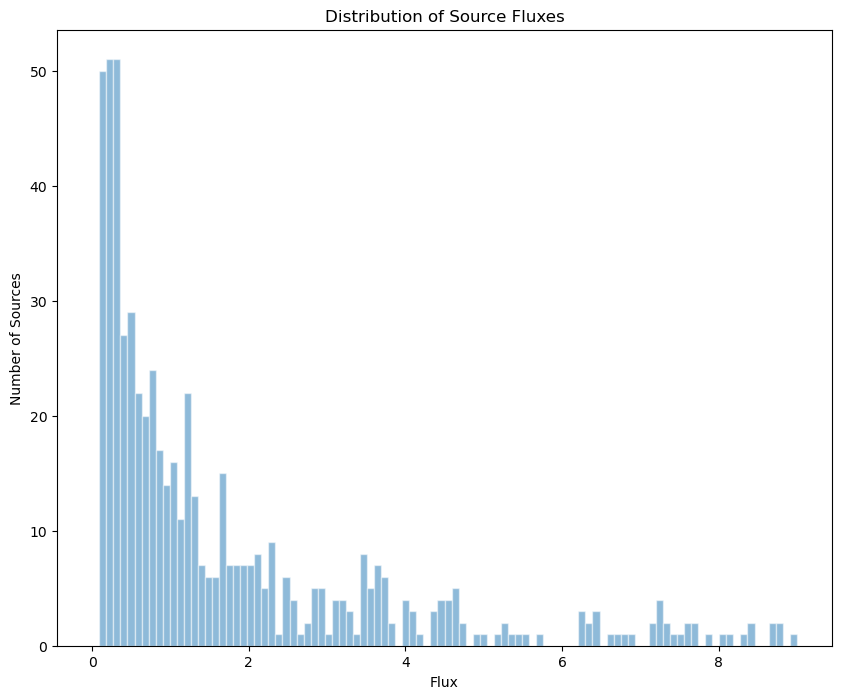

In [51]:
# get flux values
flux = objects['flux']

# number of detected sources
print("Number of sources detected:", len(objects))

# histogram of fluxes
plt.hist(flux, bins=100, range=(0,9), alpha=0.5, edgecolor="white")
plt.xlabel("Flux")
plt.ylabel("Number of Sources")
plt.title("Distribution of Source Fluxes")
plt.show()

In [52]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation:", std_flux)

Mean flux: 11.134128343008404
Median flux: 1.2310150861740112
Standard deviation: 56.83362382416208


In [53]:
# largest flux value
max_flux = np.max(flux)

# number of standard deviations from the mean
sigma_away = (max_flux - mean_flux) / std_flux

print("Largest flux value:", max_flux)
print("Number of standard deviations from the mean:", sigma_away)

Largest flux value: 1190.970947265625
Number of standard deviations from the mean: 20.75948601435167
